## 1. Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Wine Quality Dataset

In [3]:
from pathlib import Path

local_file = Path("winequality-red.csv")

if local_file.exists():
    df = pd.read_csv(local_file, sep=";")
    print("Dataset loaded from local file.")
else:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url, sep=";")
    print("Dataset downloaded from the UCI repository.")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset downloaded from the UCI repository.
Dataset loaded successfully.
Shape: (1599, 12)


## 3. View the First Few Records

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 4. Dataset Shape

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1599
Number of columns: 12


## 5. Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 6. Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 7. Check Missing Values

In [8]:
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values are present.")

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No missing values found.


## 8. Check Duplicate Rows

In [9]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 240


### Remove Duplicate Rows

In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape after removing duplicates: (1359, 12)
Remaining duplicate rows: 0


## 9. Distribution of Original Wine Quality

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


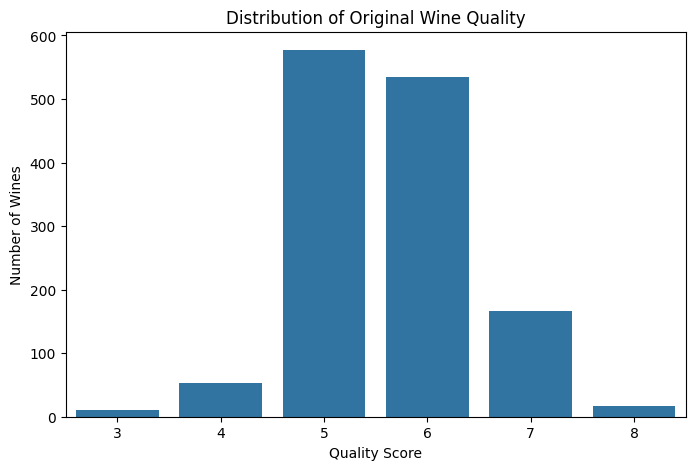

In [11]:
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Distribution of Original Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

## 10. Create the Classification Target

The original `quality` variable is converted into a binary target:

- `0` = Bad wine (`quality < 6`)
- `1` = Good wine (`quality >= 6`)


In [12]:
df["quality_label"] = (df["quality"] >= 6).astype(int)

df[["quality", "quality_label"]].head(10)

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0
5,5,0
6,7,1
7,7,1
8,5,0
9,5,0


## 11. Check Good vs Bad Wine Distribution

Bad wines (0): 640
Good wines (1): 719


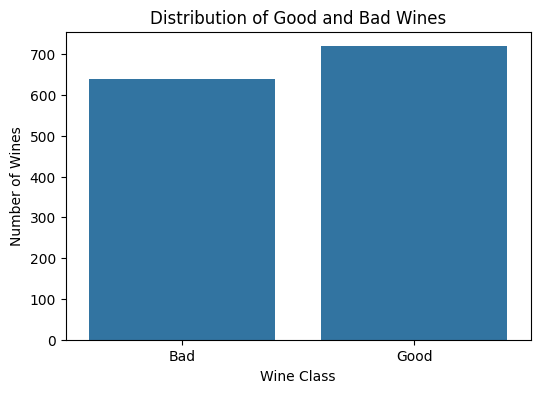

In [13]:
class_counts = df["quality_label"].value_counts().sort_index()

print("Bad wines (0):", class_counts.get(0, 0))
print("Good wines (1):", class_counts.get(1, 0))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="quality_label")
plt.title("Distribution of Good and Bad Wines")
plt.xlabel("Wine Class")
plt.ylabel("Number of Wines")
plt.xticks([0, 1], ["Bad", "Good"])
plt.show()

## 12. Feature and Target Separation

In [14]:
# Do not use the original quality score as an input feature.
# It is the information from which our classification target was created.

X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(list(X.columns))

Feature shape: (1359, 11)
Target shape: (1359,)

Feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 13. Split Data into Training and Testing Sets

We use:
- 80% data for training
- 20% data for testing
- `random_state=42` for reproducibility
- `stratify=y` to preserve the Good/Bad class proportion


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training samples: 1087
Testing samples : 272

Training class distribution:
quality_label
0    0.471021
1    0.528979
Name: proportion, dtype: float64

Testing class distribution:
quality_label
0    0.470588
1    0.529412
Name: proportion, dtype: float64


# 14. Model 1 – Decision Tree


In [16]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


### Decision Tree Evaluation

In [18]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)

print("Decision Tree")
print("---------------------------")
print(f"Accuracy : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision: {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"Recall   : {dt_recall:.4f} ({dt_recall*100:.2f}%)")

Decision Tree
---------------------------
Accuracy : 0.6250 (62.50%)
Precision: 0.6419 (64.19%)
Recall   : 0.6597 (65.97%)


# 15. Model 2 – Gaussian Naive Bayes

In [19]:
naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

nb_pred = naive_bayes.predict(X_test)

print("Naive Bayes training completed.")

Naive Bayes training completed.


### Naive Bayes Evaluation

In [20]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, zero_division=0)
nb_recall = recall_score(y_test, nb_pred, zero_division=0)

print("Naive Bayes")
print("---------------------------")
print(f"Accuracy : {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")
print(f"Precision: {nb_precision:.4f} ({nb_precision*100:.2f}%)")
print(f"Recall   : {nb_recall:.4f} ({nb_recall*100:.2f}%)")

Naive Bayes
---------------------------
Accuracy : 0.7243 (72.43%)
Precision: 0.7634 (76.34%)
Recall   : 0.6944 (69.44%)


# 16. Model 3 – Random Forest

In [21]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


### Random Forest Evaluation

In [22]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)

print("Random Forest")
print("---------------------------")
print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"Recall   : {rf_recall:.4f} ({rf_recall*100:.2f}%)")

Random Forest
---------------------------
Accuracy : 0.7500 (75.00%)
Precision: 0.7794 (77.94%)
Recall   : 0.7361 (73.61%)


# 17. Compare All Three Algorithms

In [24]:
results = pd.DataFrame({
    "Algorithm": [
        "Decision Tree",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        nb_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        nb_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        nb_recall,
        rf_recall
    ]
})

results

,Algorithm,Accuracy,Precision,Recall
0,Decision Tree,0.625000,0.641892,0.659722
1,Naive Bayes,0.724265,0.763359,0.694444
2,Random Forest,0.750000,0.779412,0.736111


### Results in Percentage

In [25]:
results_percentage = results.copy()

metric_columns = ["Accuracy", "Precision", "Recall"]
results_percentage[metric_columns] = results_percentage[metric_columns] * 100

results_percentage.round(2)

,Algorithm,Accuracy,Precision,Recall
0,Decision Tree,62.50,64.19,65.97
1,Naive Bayes,72.43,76.34,69.44
2,Random Forest,75.00,77.94,73.61


# 18. Comparison Graph

The following graph compares Accuracy, Precision, and Recall for all three algorithms.


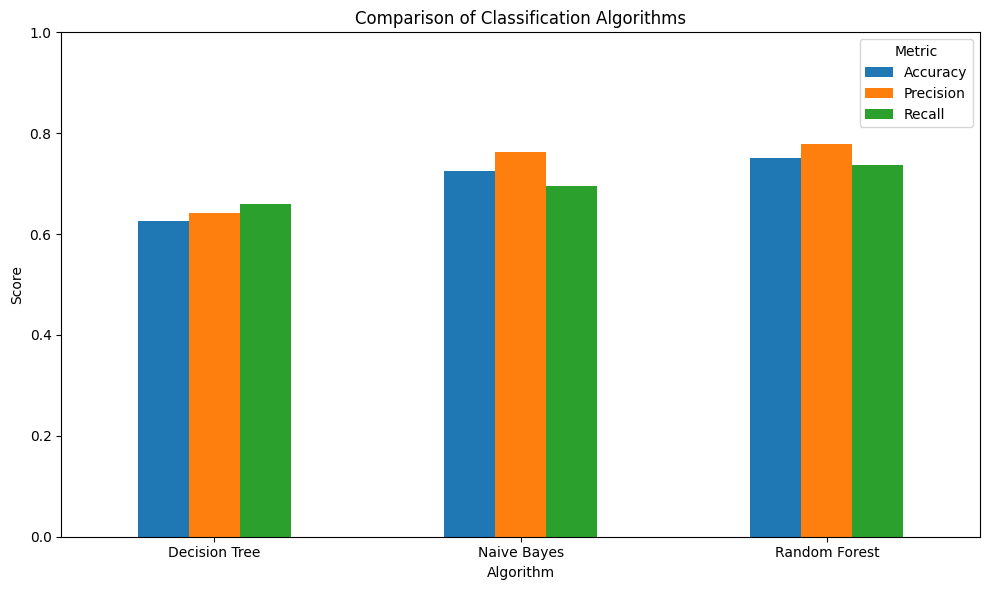

In [26]:
ax = results.set_index("Algorithm")[metric_columns].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 19. Identify the Best Model

In [31]:
best_accuracy = results.loc[results["Accuracy"].idxmax(), "Algorithm"]
best_precision = results.loc[results["Precision"].idxmax(), "Algorithm"]
best_recall = results.loc[results["Recall"].idxmax(), "Algorithm"]

print("Best Accuracy :", best_accuracy)
print("Best Precision:", best_precision)
print("Best Recall   :", best_recall)

Best Accuracy : Random Forest
Best Precision: Random Forest
Best Recall   : Random Forest


# 20. Feature Importance – Random Forest

Random Forest can estimate how useful each input feature was for the classification task.


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
10,alcohol,0.213198
9,sulphates,0.121831
1,volatile acidity,0.108305
6,total sulfur dioxide,0.091078
7,density,0.082844
4,chlorides,0.071986
0,fixed acidity,0.068659
8,pH,0.064993
2,citric acid,0.060122
5,free sulfur dioxide,0.059803


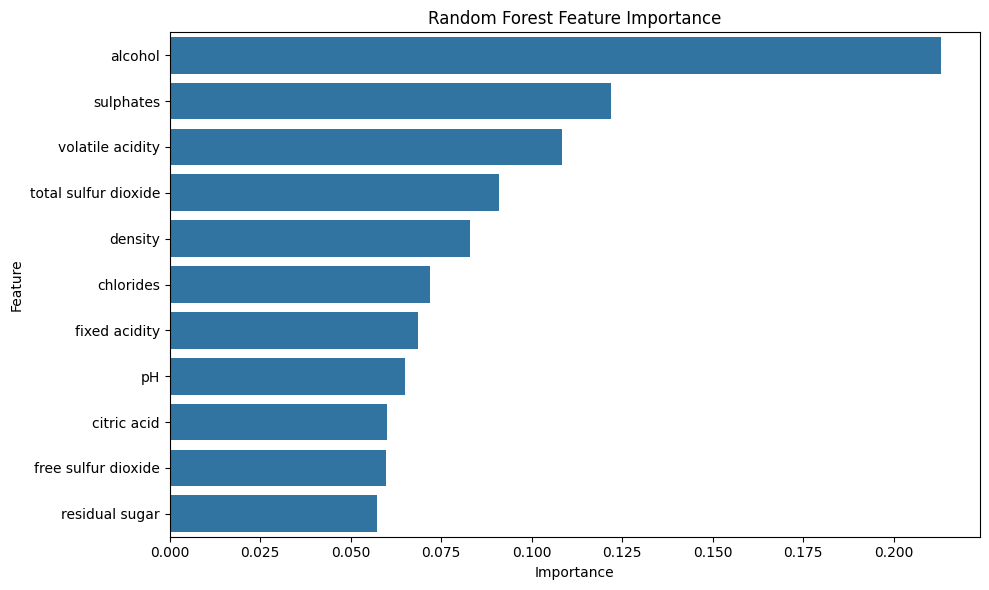

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 21. Final Comparison Table


In [34]:
final_table = results_percentage.copy()
final_table[["Accuracy", "Precision", "Recall"]] = final_table[
    ["Accuracy", "Precision", "Recall"]
].round(2)

final_table

,Algorithm,Accuracy,Precision,Recall
0,Decision Tree,62.50,64.19,65.97
1,Naive Bayes,72.43,76.34,69.44
2,Random Forest,75.00,77.94,73.61


# 22. Conclusion



In [35]:
best_overall_index = (
    results["Accuracy"] +
    results["Precision"] +
    results["Recall"]
).idxmax()

best_overall_model = results.loc[best_overall_index, "Algorithm"]

print("CONCLUSION")
print("=" * 70)
print(
    f"Among the three tested algorithms, {best_overall_model} "
    "achieved the highest combined score across Accuracy, Precision, and Recall "
    "for this experiment."
)
print(
    f"The highest Accuracy was obtained by {best_accuracy}, "
    f"the highest Precision by {best_precision}, and "
    f"the highest Recall by {best_recall}."
)
print(
    "The final choice of model should consider the required metric, "
    "the cost of false positives and false negatives, and the intended application."
)

CONCLUSION
Among the three tested algorithms, Random Forest achieved the highest combined score across Accuracy, Precision, and Recall for this experiment.
The highest Accuracy was obtained by Random Forest, the highest Precision by Random Forest, and the highest Recall by Random Forest.
The final choice of model should consider the required metric, the cost of false positives and false negatives, and the intended application.
